# VisionWear AI's kleding AI

## 0 Teaminformatie

- **Team naam**: Groep 5
- **Namen**: Imran Funna, Rinesh Nanda
- **Kaggle Imran**: imranfunna
- **Kaggle Rinesh**:

## 1 Inleiding


VisionWear AI is een modetechnologiebedrijf dat geavanceerde systemen ontwikkelt voor webshops, modehuizen en online kledingplatforms waardoor zij kleding automatisch kunnen herkennen, beschrijven en ontwerpen kunnen genereren. Hun doel is dan ook om de mode-industrie te revolutioneren met AI.

Het belangrijkste product van VisionWear AI is een intelligent modesysteem dat kleding automatisch kan detecteren en beschrijven, en nieuwe kleding kan genereren. Om dit systeem te kunnen verbeteren heeft VisionWear AI een dataset samengesteld met modefoto's, inclusief zowel de labels als de beschrijvingen. De combinatie van beeld, tekst en generatie is uitdagend, maar vormt een realistische basis voor het bouwen van deep learning-modellen.

Aan ons, een team van junior data scientists, wordt gevraagd om te helpen door verschillende AI-modellen te ontwerpen en te trainen die bijdragen aan deze innovatieve modepipeline.

# 2 Dataset

Voor het bouwen van de AI-modellen hebben we data gekregen. Dat zijn twee soorten data.

Objectdetectie Data (Deel 1):

- Images: 2145 trainingsfoto's en 537 testfoto's met kledingstukken en accessoires.

- Labels: Bounding-box coördinaten en itemklassen (0 t/m 9 zoals sunglasses, jackets en shoes).

De trainingsfoto's en bijbehorende tekstbestanden zijn georganiseerd in een gestructureerde mappenstructuur. Wij zullen dit gebruiken als input voor een objectdetectiemodel.

Fashion Caption Data (Deel 2 & 3):

- Modeafbeeldingen (H&M Fashion Dataset)

- Targetvariabele (Modieuze productbeschrijvingen en labels)

## 3 EDA

### 3.1 Importeren van libraries

In [3]:
!pip install -q datasets pillow matplotlib pandas numpy

import os
import random
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd
from datasets import load_dataset
from PIL import Image

### 3.2 Paden instellen en datasetstructuur controleren

In [4]:
import os

DATA_DIR = "/content"

TRAIN_DIR = os.path.join(DATA_DIR, "Train")
TEST_DIR = os.path.join(DATA_DIR, "Test")

print("TRAIN_DIR:", os.listdir(TRAIN_DIR))
print("TEST_DIR:", os.listdir(TEST_DIR))

# zoekt automatisch de juiste image/label mappen
def find_subfolder(parent, possible_names):
    for name in possible_names:
        path = os.path.join(parent, name)
        if os.path.exists(path):
            return path
    return None

TRAIN_IMAGE_DIR = find_subfolder(TRAIN_DIR, ["images", "Images", "image", "Image"])
TRAIN_LABEL_DIR = find_subfolder(TRAIN_DIR, ["labels", "Labels", "label", "Label"])
TEST_IMAGE_DIR = find_subfolder(TEST_DIR, ["images", "Images", "image", "Image"])

print("TRAIN_IMAGE_DIR:", TRAIN_IMAGE_DIR)
print("TRAIN_LABEL_DIR:", TRAIN_LABEL_DIR)
print("TEST_IMAGE_DIR:", TEST_IMAGE_DIR)

print("Train images:", len(os.listdir(TRAIN_IMAGE_DIR)))
print("Train labels:", len(os.listdir(TRAIN_LABEL_DIR)))
print("Test images:", len(os.listdir(TEST_IMAGE_DIR)))

FileNotFoundError: [WinError 3] The system cannot find the path specified: '/content\\Train'

In [ ]:
import os

DATA_DIR = "/content"

TRAIN_DIR = os.path.join(DATA_DIR, "Train")
TEST_DIR = os.path.join(DATA_DIR, "Test")

def find_subfolder(parent, possible_names):
    for name in possible_names:
        path = os.path.join(parent, name)
        if os.path.exists(path):
            return path
    return None

TRAIN_IMAGE_DIR = find_subfolder(TRAIN_DIR, ["images", "Images"])
TRAIN_LABEL_DIR = find_subfolder(TRAIN_DIR, ["labels", "Labels"])
TEST_IMAGE_DIR = find_subfolder(TEST_DIR, ["images", "Images"])

print(TRAIN_IMAGE_DIR)
print(TRAIN_LABEL_DIR)
print(TEST_IMAGE_DIR)

/content/Train/Images
/content/Train/Labels
/content/Test/Images


### 3.3 Klassen definiëren

In [ ]:
CLASS_NAMES = {
    0: "sunglass",
    1: "hat",
    2: "jacket",
    3: "shirt",
    4: "pants",
    5: "shorts",
    6: "skirt",
    7: "dress",
    8: "bag",
    9: "shoe"
}

### 3.4 YOLO-labels inlezen

In [ ]:
def read_yolo_label(label_path):
    labels = []

    with open(label_path, "r") as file:
        for line in file.readlines():
            values = line.strip().split()

            if len(values) == 5:
                class_id = int(values[0])

                labels.append({
                    "class_id": class_id,
                    "class_name": CLASS_NAMES[class_id],
                    "center_x": float(values[1]),
                    "center_y": float(values[2]),
                    "width": float(values[3]),
                    "height": float(values[4])
                })

    return labels

### 3.5 Labeldata omzetten naar een dataframe

In [ ]:
image_files = sorted(os.listdir(TRAIN_IMAGE_DIR))
rows = []

for image_file in image_files:
    image_name = os.path.splitext(image_file)[0]
    label_path = os.path.join(TRAIN_LABEL_DIR, image_name + ".txt")

    if os.path.exists(label_path):
        labels = read_yolo_label(label_path)

        for label in labels:
            rows.append({
                "image_file": image_file,
                **label
            })

labels_df = pd.DataFrame(rows)

display(labels_df.head())
print("Aantal annotaties:", len(labels_df))
print("Aantal unieke afbeeldingen:", labels_df["image_file"].nunique())

,image_file,class_id,class_name,center_x,center_y,width,height
0,1.jpg,8,bag,0.68875,0.639167,0.3025,0.118333
1,1.jpg,7,dress,0.65000,0.429167,0.4150,0.411667
2,1.jpg,9,shoe,0.61000,0.900833,0.1450,0.118333
3,100034.jpg,3,shirt,0.56875,0.257500,0.3275,0.175000
4,100034.jpg,8,bag,0.70625,0.480833,0.2125,0.188333


Aantal annotaties: 8298
Aantal unieke afbeeldingen: 2145


### 3.6 Verdeling van objectklassen

,count
class_name,
shoe,2081
shirt,1486
bag,1188
jacket,777
skirt,697
dress,550
pants,508
shorts,395
sunglass,343


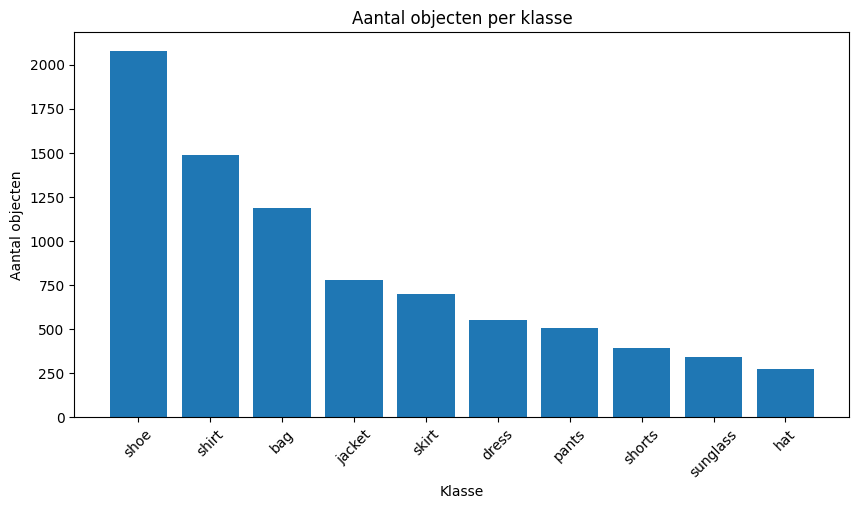

In [ ]:
class_counts = labels_df["class_name"].value_counts()

display(class_counts)

plt.figure(figsize=(10, 5))
plt.bar(class_counts.index, class_counts.values)
plt.title("Aantal objecten per klasse")
plt.xlabel("Klasse")
plt.ylabel("Aantal objecten")
plt.xticks(rotation=45)
plt.show()

### 3.7 Aantal objecten per afbeelding

Gemiddeld aantal objecten per afbeelding: 3.8685314685314687
Min: 1
Max: 7


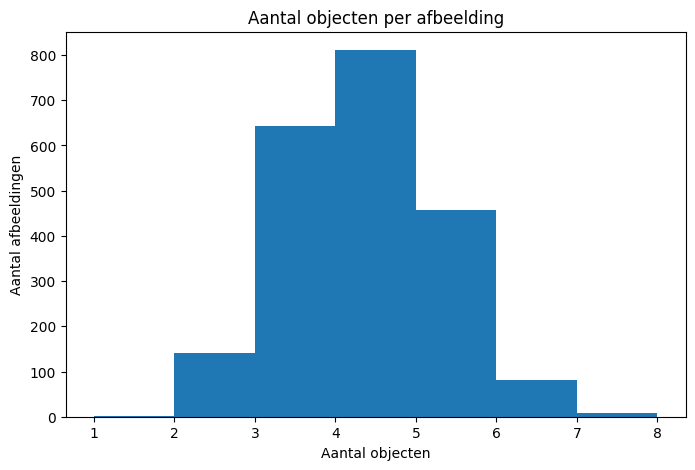

In [ ]:
objects_per_image = labels_df.groupby("image_file").size()

print("Gemiddeld aantal objecten per afbeelding:", objects_per_image.mean())
print("Min:", objects_per_image.min())
print("Max:", objects_per_image.max())

plt.figure(figsize=(8, 5))
plt.hist(objects_per_image, bins=range(1, objects_per_image.max() + 2))
plt.title("Aantal objecten per afbeelding")
plt.xlabel("Aantal objecten")
plt.ylabel("Aantal afbeeldingen")
plt.show()

### 3.8 Analyse van bounding-box groottes

,width,height,box_area
count,8298.000000,8298.000000,8298.000000
mean,0.252748,0.211808,0.062582
std,0.111025,0.127133,0.055055
min,0.015000,0.010000,0.000225
25%,0.162500,0.108333,0.018333
50%,0.245000,0.186667,0.045046
75%,0.330000,0.298333,0.095850
max,0.772500,0.776667,0.460350


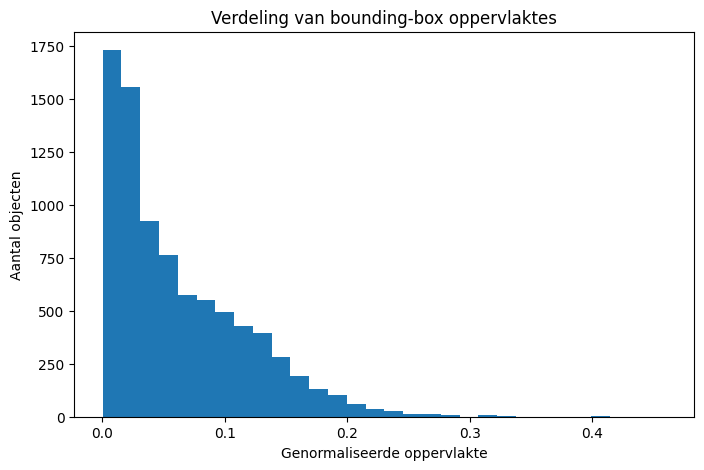

In [ ]:
labels_df["box_area"] = labels_df["width"] * labels_df["height"]

display(labels_df[["width", "height", "box_area"]].describe())

plt.figure(figsize=(8, 5))
plt.hist(labels_df["box_area"], bins=30)
plt.title("Verdeling van bounding-box oppervlaktes")
plt.xlabel("Genormaliseerde oppervlakte")
plt.ylabel("Aantal objecten")
plt.show()

### 3.9 Afbeeldingen visualiseren met bounding boxes

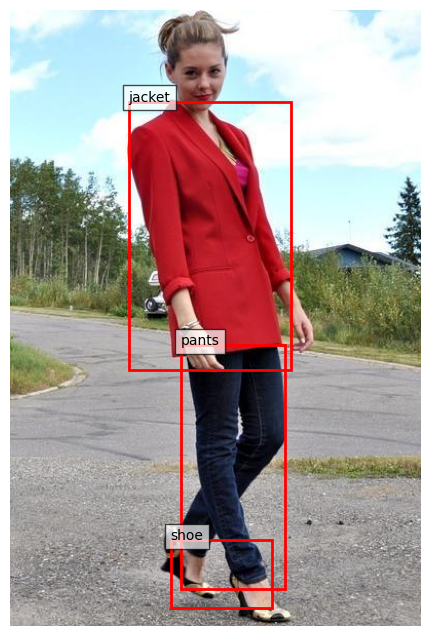

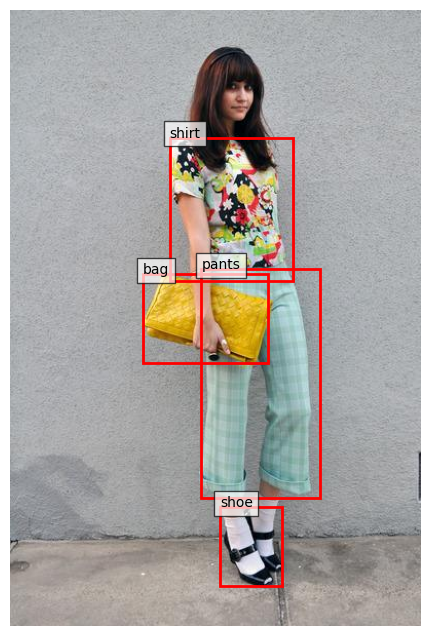

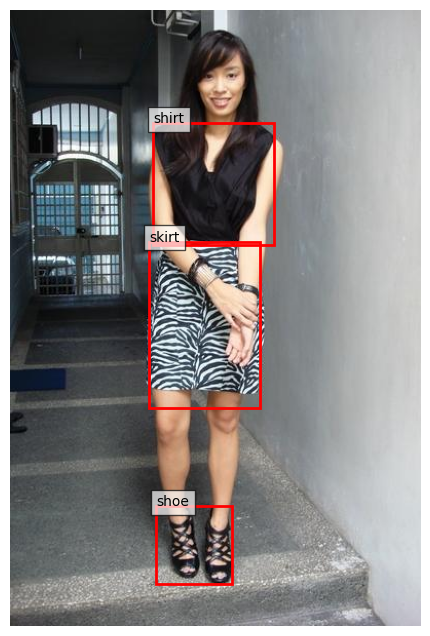

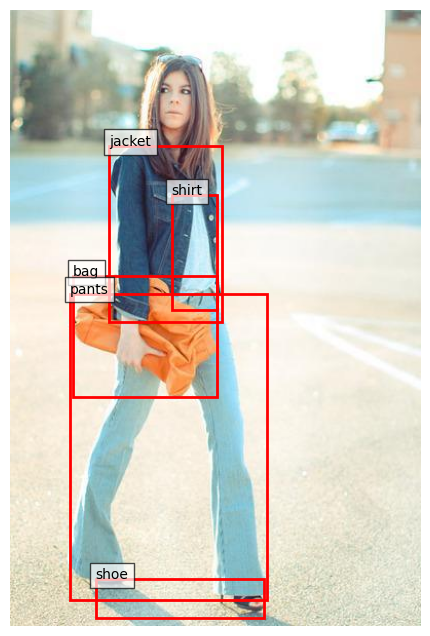

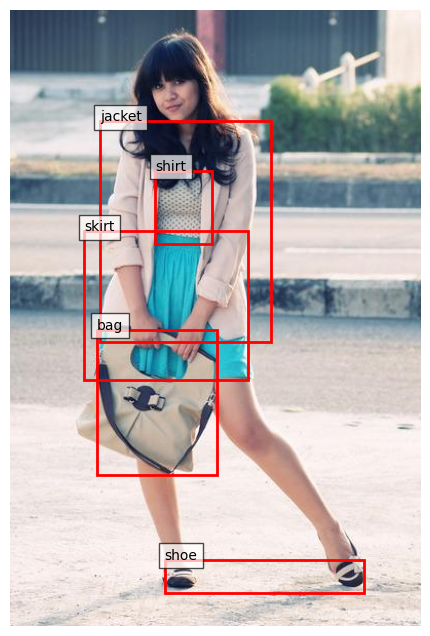

In [ ]:
def plot_image_with_boxes(image_file):
    image_path = os.path.join(TRAIN_IMAGE_DIR, image_file)
    label_path = os.path.join(
        TRAIN_LABEL_DIR,
        os.path.splitext(image_file)[0] + ".txt"
    )

    image = Image.open(image_path).convert("RGB")
    image_width, image_height = image.size

    labels = read_yolo_label(label_path)

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(image)

    for label in labels:
        center_x = label["center_x"] * image_width
        center_y = label["center_y"] * image_height
        box_width = label["width"] * image_width
        box_height = label["height"] * image_height

        x_min = center_x - box_width / 2
        y_min = center_y - box_height / 2

        rectangle = patches.Rectangle(
            (x_min, y_min),
            box_width,
            box_height,
            linewidth=2,
            edgecolor="red",
            facecolor="none"
        )

        ax.add_patch(rectangle)
        ax.text(
            x_min,
            y_min,
            label["class_name"],
            fontsize=10,
            bbox={"facecolor": "white", "alpha": 0.7}
        )

    ax.axis("off")
    plt.show()

for image_file in random.sample(image_files, 5):
    plot_image_with_boxes(image_file)

### 3.10 H&M Fashion Caption dataset laden

In [ ]:
!pip install -q datasets

from datasets import load_dataset

caption_dataset = load_dataset("tomytjandra/h-and-m-fashion-caption-12k")
train = caption_dataset["train"]

print(caption_dataset)
print(train.features)
print("Aantal voorbeelden:", len(train))

DatasetDict({
    train: Dataset({
        features: ['text', 'image'],
        num_rows: 12437
    })
})
{'text': Value('string'), 'image': Image(mode=None, decode=True)}
Aantal voorbeelden: 12437


### 3.11 Voorbeelden uit de caption dataset visualiseren

solid dark blue fitted top in soft stretch jersey with a wide neckline and long sleeves


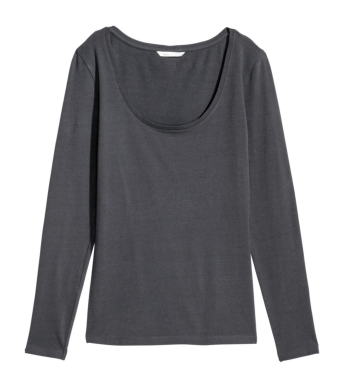

In [ ]:
sample = caption_train[0]

print(sample["text"])

plt.imshow(sample["image"])
plt.axis("off")
plt.show()

### 3.12 Lengte van captions analyseren

In [ ]:
# Bereken de lengte van alle captions

caption_lengths = [len(sample["text"].split()) for sample in train]

print(f"Aantal captions: {len(caption_lengths)}")
print(f"Gemiddelde lengte: {np.mean(caption_lengths):.2f} woorden")
print(f"Mediaan: {np.median(caption_lengths)} woorden")
print(f"Kortste caption: {np.min(caption_lengths)} woorden")
print(f"Langste caption: {np.max(caption_lengths)} woorden")

Aantal captions: 12437
Gemiddelde lengte: 27.99 woorden
Mediaan: 28.0 woorden
Kortste caption: 12 woorden
Langste caption: 45 woorden


### 3.13 Meest voorkomende woorden in captions

In [ ]:
words = []

for sample in train:
    words.extend(sample["text"].lower().split())

counter = Counter(words)

top20 = pd.DataFrame(
    counter.most_common(20),
    columns=["Woord", "Frequentie"]
)

top20

,Woord,Frequentie
0,a,21431
1,and,19752
2,with,19069
3,the,17791
4,in,13837
5,at,11041
6,solid,6805
7,sleeves,5387
8,front,4953
9,back,4750


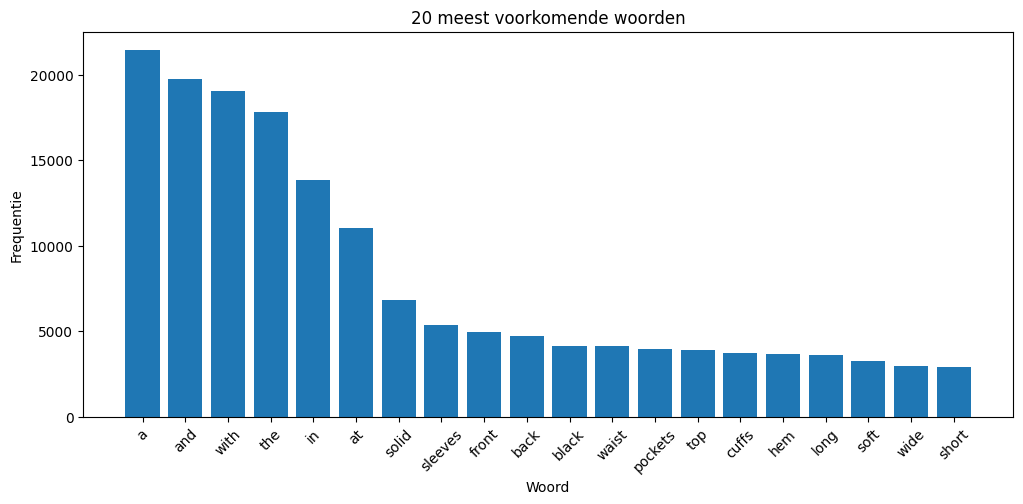

In [ ]:
plt.figure(figsize=(12,5))

plt.bar(top20["Woord"], top20["Frequentie"])

plt.xticks(rotation=45)

plt.title("20 meest voorkomende woorden")
plt.xlabel("Woord")
plt.ylabel("Frequentie")

plt.show()

### 3.14 Overlap tussen objectdetectie- en caption dataset

In [ ]:
# Controleer welke kledingcategorieën uit de objectdetectiedataset
# ook voorkomen in de captions

fashion_items = [
    "dress",
    "shirt",
    "top",
    "jacket",
    "pants",
    "trousers",
    "shorts",
    "skirt",
    "bag",
    "shoe",
    "hat",
    "sunglasses"
]

results = []

captions = [sample["text"].lower() for sample in train]

for item in fashion_items:
    count = sum(item in caption for caption in captions)

    results.append({
        "Kledingstuk": item,
        "Aantal vermeldingen": count
    })

overlap_df = pd.DataFrame(results)

display(overlap_df)

,Kledingstuk,Aantal vermeldingen
0,dress,2172
1,shirt,1499
2,top,3464
3,jacket,791
4,pants,6
5,trousers,1071
6,shorts,499
7,skirt,1420
8,bag,113
9,shoe,0


### 3.15 Belangrijkste bevindingen van de EDA

Uit de exploratieve data-analyse blijkt dat de objectdetectiedataset bestaat uit **2145 afbeeldingen** met in totaal **8298 geannoteerde objecten**. Gemiddeld bevat een afbeelding ongeveer **3,87 objecten**, waarbij het minimum één object en het maximum zeven objecten is. Dit betekent dat de meeste afbeeldingen meerdere kledingstukken of accessoires bevatten. Hierdoor is de dataset geschikt voor een objectdetectiemodel dat meerdere objecten binnen één afbeelding moet herkennen.

De verdeling van de objectklassen is niet gelijk. Schoenen komen met **2081 annotaties** het vaakst voor, gevolgd door shirts (**1486**) en tassen (**1188**). Hoeden (**273**) en zonnebrillen (**343**) zijn juist veel minder vertegenwoordigd. Deze onbalans kan invloed hebben op de prestaties van het model, omdat modellen doorgaans beter leren van klassen waarvoor veel trainingsvoorbeelden beschikbaar zijn dan van klassen die minder vaak voorkomen.

De analyse van de bounding-boxes laat zien dat de meeste objecten een relatief klein deel van de afbeelding beslaan. De gemiddelde genormaliseerde oppervlakte bedraagt ongeveer **0,063**, terwijl de verdeling sterk naar kleinere objecten verschuift. Dit betekent dat het model niet alleen grote kledingstukken moet herkennen, maar ook kleinere objecten zoals accessoires.

De H&M Fashion Caption dataset bevat **12.437 afbeeldingen** met Engelstalige productbeschrijvingen. De captions bestaan gemiddeld uit **28 woorden**, met een minimum van **12** en een maximum van **45** woorden. Hierdoor bevatten de beschrijvingen voldoende detail om een image captioning model te trainen. De meest voorkomende woorden zijn onder andere *a*, *and*, *with*, *the*, *solid*, *sleeves*, *black*, *waist*, *pockets* en *top*. Dit laat zien dat de captions niet alleen beschrijven welk kledingstuk op de afbeelding staat, maar ook eigenschappen zoals kleur, pasvorm, materiaal en andere kenmerken.

Tot slot is gekeken naar de overlap tussen de objectdetectiedataset en de captiondataset. Hieruit blijkt dat categorieën zoals **dress**, **shirt**, **top**, **jacket**, **trousers**, **shorts**, **skirt** en **hat** in beide datasets voorkomen. Tegelijkertijd zijn er verschillen in de gebruikte terminologie. Zo wordt in de captiondataset veel vaker het woord **trousers** gebruikt dan **pants**. Daarnaast komen woorden zoals **shoe** en **sunglasses** vrijwel niet voor, terwijl deze categorieën wel aanwezig zijn in de objectdetectiedataset. Dit laat zien dat beide datasets verschillende benamingen gebruiken voor vergelijkbare kledingstukken. Bij het combineren van de objectdetectie- en captioningmodellen moet hiermee rekening worden gehouden, bijvoorbeeld door gebruik te maken van een mapping tussen synoniemen.

Op basis van de EDA kan worden geconcludeerd dat beide datasets goed aansluiten op de doelstellingen van deze opdracht. De objectdetectiedataset bevat voldoende variatie om een model te trainen dat kledingstukken kan lokaliseren, terwijl de H&M Fashion Caption dataset voldoende gedetailleerde beschrijvingen bevat om een model te trainen dat passende tekstbijschriften kan genereren. De belangrijkste aandachtspunten zijn de ongelijke verdeling van de objectklassen en de verschillen in terminologie tussen beide datasets.